# 📊 Análise Exploratória de Dados — NPS E-commerce
**Tech Challenge Fase 1 — POSTECH**

---

### 🎯 Objetivo
Entender por que as notas de NPS variam tanto e identificar quais fatores da jornada de compra estão associados às notas mais baixas.

### 🗂️ Estrutura do notebook
1. Importações e configurações
2. Carregamento e inspeção inicial dos dados
3. Limpeza e preparação
4. Análise da variável-alvo (NPS)
5. Análise de correlações
6. Análise por etapa da jornada
7. Perfil do cliente: detrator vs promotor
8. Análise por região
9. Recompra: o indicador que valida tudo
10. Resumo final dos insights

---
> 💡 **Como ler este notebook:** cada célula tem um bloco de código e uma explicação logo acima. Rode as células **em ordem**, de cima para baixo, pressionando `Shift + Enter`.
>
> ⚠️ **Boas práticas aplicadas aqui:** nenhum número está escrito na mão. Todos os valores nos textos são **calculados automaticamente a partir dos dados** — se a base mudar, os textos se atualizam sozinhos.

---
## 1. Importações e configurações

| Biblioteca | Para que serve |
|---|---|
| `pandas` | Carregar, limpar e manipular tabelas de dados |
| `numpy` | Cálculos matemáticos e arrays |
| `matplotlib` | Criar gráficos básicos |
| `seaborn` | Gráficos estatísticos mais elegantes |

> 🧠 **Aprenda:** `import pandas as pd` significa "traga a biblioteca pandas e vou chamá-la de `pd` para digitar menos".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


---
## 2. Carregamento e inspeção inicial dos dados

> 🧠 **Aprenda:** o `r` antes do caminho é essencial no Windows. Sem ele, as barras `\` do caminho são interpretadas como comandos especiais pelo Python e geram erro.
>
> **Ajuste o caminho abaixo para onde o CSV está no seu computador.**

In [4]:
# ⚠️ AJUSTE ESTE CAMINHO para onde o CSV está no seu computador
# Use r'...' para evitar erros com barras no Windows
CAMINHO_CSV = r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\desafio_nps_fase_1 (1).csv'

df = pd.read_csv(CAMINHO_CSV)

# Calculamos as dimensões a partir do próprio dado — sem hardcode
n_linhas, n_colunas = df.shape

print(f'📐 Dimensões da tabela: {n_linhas} linhas × {n_colunas} colunas')
print(f'   → {n_linhas} clientes analisados')
print(f'   → {n_colunas} variáveis por cliente')

📐 Dimensões da tabela: 2500 linhas × 19 colunas
   → 2500 clientes analisados
   → 19 variáveis por cliente


In [3]:
# Primeiras linhas da tabela
df.head(5)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


In [5]:
# Tipos de dados por coluna
# int64 = inteiro | float64 = decimal | object = texto
print('📋 Tipos de dados por coluna:')
print(df.dtypes)

📋 Tipos de dados por coluna:
customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object


In [6]:
# Verificação de valores nulos
# .isnull() marca cada célula vazia como True
# .sum() conta quantas True existem por coluna
total_nulos = df.isnull().sum().sum()

print('🔍 Verificação de valores nulos:')
if total_nulos == 0:
    print(f'✅ Nenhum valor nulo encontrado — base completa com {n_linhas} registros.')
else:
    colunas_com_nulo = df.isnull().sum()
    colunas_com_nulo = colunas_com_nulo[colunas_com_nulo > 0]
    print(f'⚠️ {total_nulos} valores nulos encontrados nas colunas abaixo:')
    print(colunas_com_nulo)

🔍 Verificação de valores nulos:
✅ Nenhum valor nulo encontrado — base completa com 2500 registros.


In [7]:
# Estatísticas descritivas
# count=registros | mean=média | std=desvio padrão | min/max=extremos
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.25,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.51,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


---
## 3. Limpeza e preparação dos dados

> 🧠 **Aprenda:** criar novas colunas a partir de colunas existentes se chama **feature engineering**.
> É uma das habilidades mais importantes em ciência de dados.

In [8]:
# Classificação NPS — padrão mundial:
# 0-6 = Detrator | 7-8 = Neutro | 9-10 = Promotor
def classificar_nps(score):
    """Recebe uma nota e retorna a categoria NPS correspondente."""
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

# Calculamos a contagem — não escrevemos os números na mão
contagem_categorias = df['nps_categoria'].value_counts()

print('✅ Coluna nps_categoria criada!')
print(contagem_categorias)

✅ Coluna nps_categoria criada!
nps_categoria
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64


In [9]:
# Faixas de atraso — agrupa dias contínuos em grupos legíveis
# pd.cut() divide valores numéricos em categorias (como um SE aninhado do Excel)
df['faixa_atraso'] = pd.cut(
    df['delivery_delay_days'],
    bins=[-1, 0, 3, 7, 100],
    labels=['Sem atraso', '1-3 dias', '4-7 dias', '8+ dias']
)

contagem_faixas = df['faixa_atraso'].value_counts().sort_index()

print('✅ Coluna faixa_atraso criada!')
print(contagem_faixas)

✅ Coluna faixa_atraso criada!
faixa_atraso
Sem atraso     277
1-3 dias      1786
4-7 dias       434
8+ dias          3
Name: count, dtype: int64


---
## 4. Análise da Variável-Alvo: NPS

> 🧠 **Aprenda:** a **variável-alvo** é o que queremos entender ou prever — aqui é o `nps_score`.
> Sempre analise ela isoladamente antes de cruzar com outras variáveis.

In [10]:
# Calculamos TUDO a partir dos dados — nenhum número é escrito na mão
nps_medio   = df['nps_score'].mean()
nps_mediana = df['nps_score'].median()
nps_std     = df['nps_score'].std()

contagem = df['nps_categoria'].value_counts()
pct      = df['nps_categoria'].value_counts(normalize=True) * 100

# Fórmula oficial do NPS: % Promotores - % Detratores
nps_empresa = pct.get('Promotor', 0) - pct.get('Detrator', 0)

print('=' * 55)
print('📊 RESUMO DO NPS')
print('=' * 55)
print(f'Média:    {nps_medio:.2f}  (escala 0–10)')
print(f'Mediana:  {nps_mediana:.2f}')
print(f'Desvio:   {nps_std:.2f}')
print()
print('Categorias:')
for cat in ['Promotor', 'Neutro', 'Detrator']:
    n   = contagem.get(cat, 0)
    pct_val = pct.get(cat, 0)
    print(f'  {cat:10s}: {n:4d} clientes  ({pct_val:.1f}%)')
print()
print(f'🎯 NPS DA EMPRESA: {nps_empresa:.0f}%')
print(f'   (fórmula: {pct.get("Promotor",0):.1f}% Promotores - {pct.get("Detrator",0):.1f}% Detratores)')
print(f'   Referência de mercado saudável: +30 a +60')
print('=' * 55)

📊 RESUMO DO NPS
Média:    4.38  (escala 0–10)
Mediana:  4.40
Desvio:   2.51

Categorias:
  Promotor  :  201 clientes  (8.0%)
  Neutro    :  448 clientes  (17.9%)
  Detrator  : 1851 clientes  (74.0%)

🎯 NPS DA EMPRESA: -66%
   (fórmula: 8.0% Promotores - 74.0% Detratores)
   Referência de mercado saudável: +30 a +60


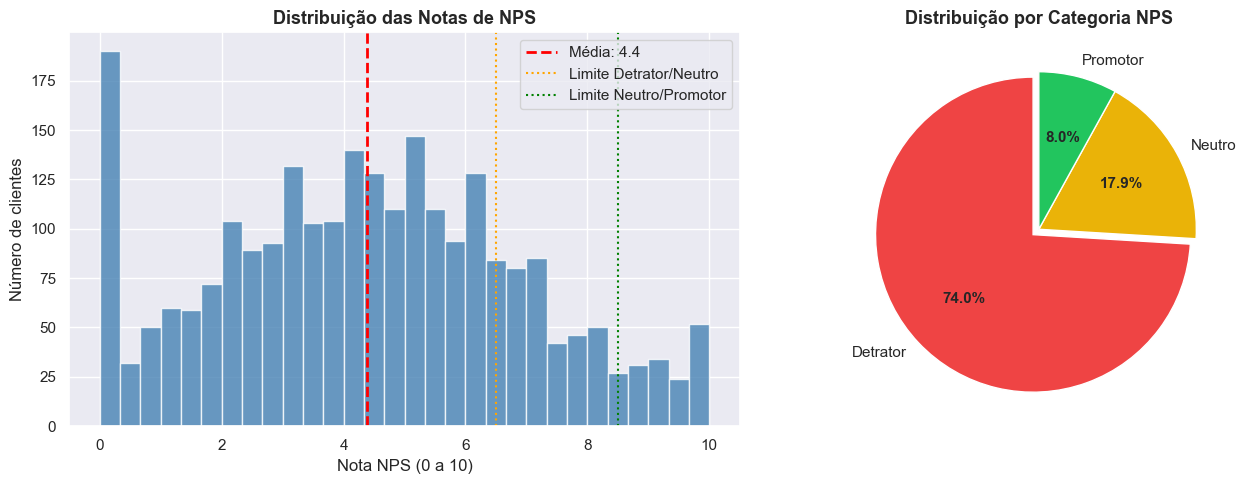


💡 INTERPRETAÇÃO:
74% dos clientes são Detratores
8% dos clientes são Promotores
18% dos clientes são Neutros


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Histograma
axes[0].hist(df['nps_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(nps_medio, color='red', linestyle='--', linewidth=2, label=f'Média: {nps_medio:.1f}')
axes[0].axvline(6.5, color='orange', linestyle=':', linewidth=1.5, label='Limite Detrator/Neutro')
axes[0].axvline(8.5, color='green',  linestyle=':', linewidth=1.5, label='Limite Neutro/Promotor')
axes[0].set_title('Distribuição das Notas de NPS', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota NPS (0 a 10)')
axes[0].set_ylabel('Número de clientes')
axes[0].legend()

# Gráfico B: Pizza — valores vêm das variáveis calculadas acima
cats   = ['Detrator', 'Neutro', 'Promotor']
vals   = [contagem.get(c, 0) for c in cats]
cores  = ['#ef4444', '#eab308', '#22c55e']
wedges, texts, autotexts = axes[1].pie(
    vals, labels=cats, colors=cores,
    autopct='%1.1f%%', startangle=90, explode=(0.05, 0, 0)
)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(11)
axes[1].set_title('Distribuição por Categoria NPS', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/01_distribuicao_nps.png', dpi=150, bbox_inches='tight')
plt.show()

# ✅ Os valores no print abaixo vêm das variáveis — não estão escritos na mão
pct_det = pct.get('Detrator', 0)
pct_prom = pct.get('Promotor',0)
pct_neut = pct.get('Neutro')
print(f'\n💡 INTERPRETAÇÃO:')
print(f'{pct_det:.0f}% dos clientes são Detratores')
print(f'{pct_prom:.0f}% dos clientes são Promotores')
print(f'{pct_neut:.0f}% dos clientes são Neutros')

---
## 5. Análise de Correlações

**Correlação** mede o quanto duas variáveis se movem juntas. Vai de -1 a +1.

| Faixa | Interpretação |
|---|---|
| 0,0 a 0,2 | Muito fraca — praticamente irrelevante |
| 0,2 a 0,4 | Fraca a moderada |
| 0,4 a 0,6 | Moderada a forte ✅ |
| 0,6 a 1,0 | Forte a muito forte 🔥 |

> 🧠 **Aprenda:** correlação **não é causalidade** — que atraso e NPS baixo andem juntos não prova que um *causa* o outro, mas é um fortíssimo indício e merece investigação.

In [12]:
# Seleciona colunas numéricas e calcula correlação com o NPS
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

correlacoes = (
    df[colunas_numericas]
    .corr()['nps_score']
    .drop('nps_score')
    .sort_values()
)

print('🔗 CORRELAÇÃO DE CADA VARIÁVEL COM O NPS:')
print('(negativo = derruba o NPS | positivo = eleva o NPS)')
print('-' * 55)

for var, val in correlacoes.items():
    barra   = int(abs(val) * 20)
    simbolo = '█' * barra
    sinal   = '🔴 ' if val < 0 else '🟢 +'
    print(f'  {var:30s} {sinal}{abs(val):.3f}  {simbolo}')

🔗 CORRELAÇÃO DE CADA VARIÁVEL COM O NPS:
(negativo = derruba o NPS | positivo = eleva o NPS)
-------------------------------------------------------
  delivery_delay_days            🔴 0.597  ███████████
  complaints_count               🔴 0.497  █████████
  customer_service_contacts      🔴 0.351  ███████
  resolution_time_days           🔴 0.191  ███
  freight_value                  🔴 0.041  
  customer_age                   🔴 0.010  
  customer_tenure_months         🔴 0.010  
  delivery_time_days             🟢 +0.001  
  items_quantity                 🟢 +0.011  
  customer_id                    🟢 +0.015  
  order_id                       🟢 +0.015  
  payment_installments           🟢 +0.024  
  discount_value                 🟢 +0.025  
  delivery_attempts              🟢 +0.028  
  order_value                    🟢 +0.037  
  csat_internal_score            🟢 +0.564  ███████████
  repeat_purchase_30d            🟢 +0.570  ███████████


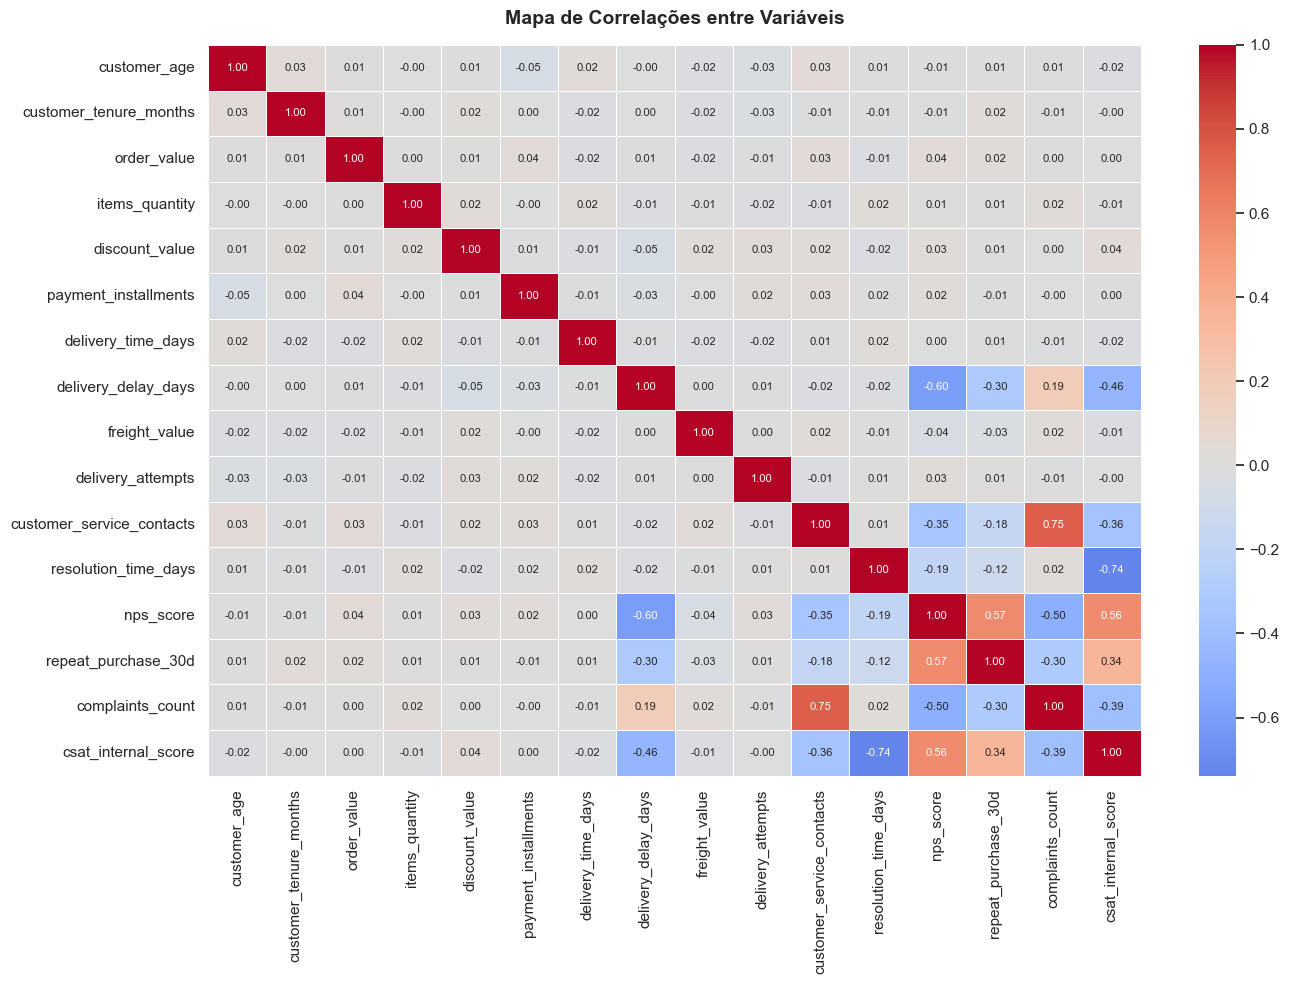


💡 COMO LER O HEATMAP:
Variável que mais derruba o NPS: delivery_delay_days (correlação: -0.597)
Variável que mais eleva o NPS:   repeat_purchase_30d (correlação: 0.570)


In [13]:
# Heatmap de correlações
# Azul = positivo | Vermelho = negativo | Branco = sem correlação
cols_corr = [c for c in colunas_numericas if c not in ['customer_id', 'order_id']]
matriz_corr = df[cols_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz_corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Mapa de Correlações entre Variáveis', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/02_heatmap_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

# ✅ Identifica os destaques automaticamente — sem escrever os nomes na mão
corr_filtrada = correlacoes.drop(['customer_id', 'order_id'], errors='ignore')
var_mais_negativa = corr_filtrada.idxmin()
var_mais_positiva = corr_filtrada.idxmax()
val_mais_negativa = corr_filtrada.min()
val_mais_positiva = corr_filtrada.max()

print('\n💡 COMO LER O HEATMAP:')
print(f'Variável que mais derruba o NPS: {var_mais_negativa} (correlação: {val_mais_negativa:.3f})')
print(f'Variável que mais eleva o NPS:   {var_mais_positiva} (correlação: {val_mais_positiva:.3f})')

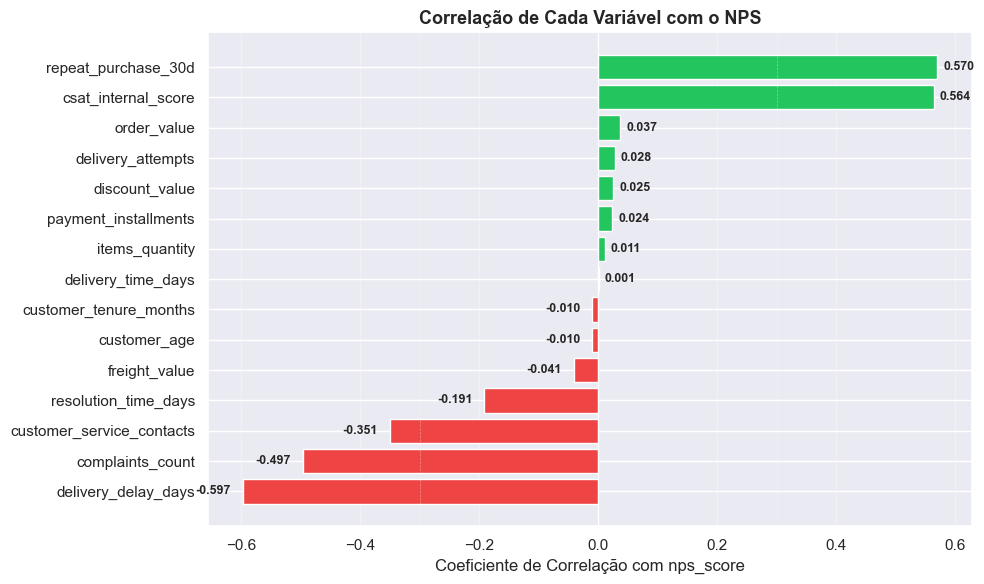

In [14]:
# Gráfico de barras horizontais das correlações
cores_barras = ['#ef4444' if v < 0 else '#22c55e' for v in corr_filtrada.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(corr_filtrada.index, corr_filtrada.values, color=cores_barras, edgecolor='white')
plt.axvline(0, color='white', linewidth=0.8)
plt.axvline( 0.3, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
plt.axvline(-0.3, color='white', linewidth=0.5, linestyle='--', alpha=0.4)

for val, bar in zip(corr_filtrada.values, bars):
    offset = -0.02 if val < 0 else 0.01
    ha     = 'right' if val < 0 else 'left'
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.title('Correlação de Cada Variável com o NPS', fontsize=13, fontweight='bold')
plt.xlabel('Coeficiente de Correlação com nps_score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/03_correlacoes_nps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Análise por Etapa da Jornada

Cruzamos cada variável da jornada com o NPS para encontrar os **pontos de ruptura** — os momentos onde a experiência do cliente quebra de vez.

> 🧠 **Aprenda:** `groupby()` agrupa os dados por uma coluna e permite calcular estatísticas de cada grupo. É equivalente a uma tabela dinâmica do Excel.

In [15]:
# ── ETAPA: ENTREGA ──────────────────────────────────────────
# Agrupa por faixa de atraso e calcula o NPS médio de cada grupo
nps_por_atraso = df.groupby('faixa_atraso', observed=True)['nps_score'].mean().round(2)

# ✅ Todos os valores vêm do cálculo — não estão escritos na mão
nps_sem_atraso = nps_por_atraso['Sem atraso']
nps_8_mais     = nps_por_atraso['8+ dias']
queda_total    = nps_sem_atraso - nps_8_mais

print('🚚 NPS MÉDIO POR FAIXA DE ATRASO:')
print('-' * 40)
for faixa, nps_val in nps_por_atraso.items():
    emoji = '🟢' if nps_val > 6 else ('🟡' if nps_val > 3 else '🔴')
    print(f'  {faixa:15s}: NPS = {nps_val:.2f}  {emoji}')

print()
print('💥 QUEDA NO NPS (comparado a quem não atrasou):')
for faixa in ['1-3 dias', '4-7 dias', '8+ dias']:
    queda = nps_sem_atraso - nps_por_atraso[faixa]
    pct_perda = queda / nps_sem_atraso * 100
    print(f'  Sem atraso → {faixa}: -{queda:.2f} pontos  ({pct_perda:.0f}% de perda)')

print()
print(f'⚠️  Na faixa 8+ dias o NPS médio cai para {nps_8_mais:.2f} — queda de {queda_total:.2f} pontos.')

🚚 NPS MÉDIO POR FAIXA DE ATRASO:
----------------------------------------
  Sem atraso     : NPS = 6.86  🟢
  1-3 dias       : NPS = 4.58  🟡
  4-7 dias       : NPS = 2.01  🔴
  8+ dias        : NPS = 0.00  🔴

💥 QUEDA NO NPS (comparado a quem não atrasou):
  Sem atraso → 1-3 dias: -2.28 pontos  (33% de perda)
  Sem atraso → 4-7 dias: -4.85 pontos  (71% de perda)
  Sem atraso → 8+ dias: -6.86 pontos  (100% de perda)

⚠️  Na faixa 8+ dias o NPS médio cai para 0.00 — queda de 6.86 pontos.


C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\2109441884.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\2109441884.py:31: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\2109441884.py:31: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\2109441884.py:32: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/04_atraso_vs_nps.png', dpi=150, bbox_inches='tight')
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\2109441884.py:32: UserWarning: Glyph 65039 (\N{V

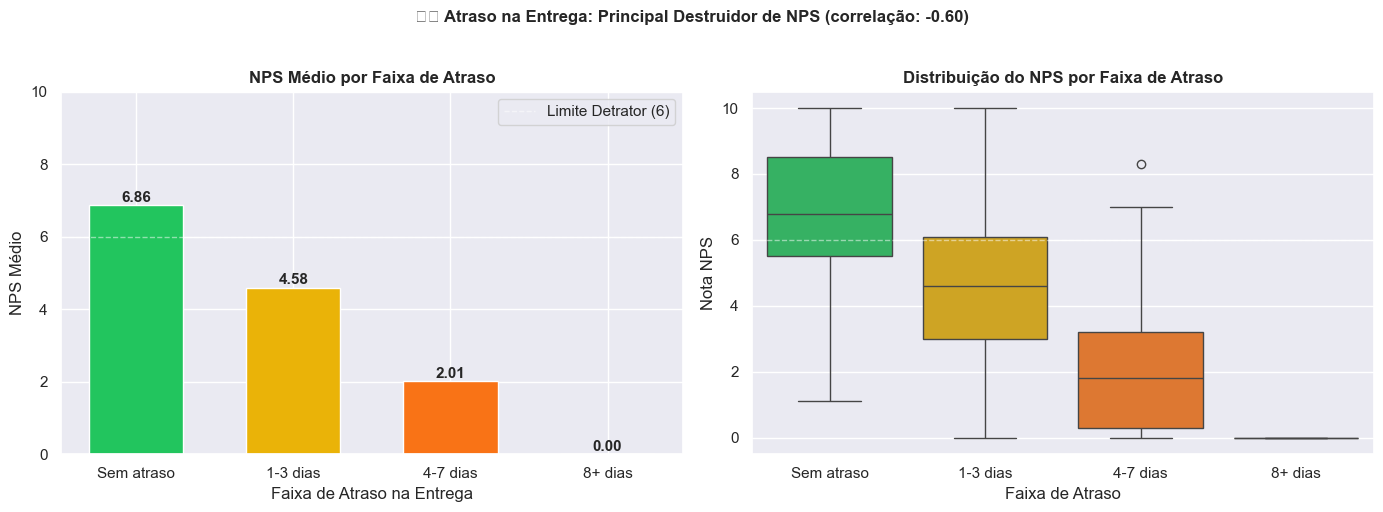


💡 COMO LER O BOXPLOT:
A linha no meio = mediana. A caixa = onde estão 50% dos clientes.
Na faixa 8+ dias, o NPS médio é 0.00 — praticamente todos são detratores.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Barras
ordem_faixas = ['Sem atraso', '1-3 dias', '4-7 dias', '8+ dias']
cores_faixa  = ['#22c55e', '#eab308', '#f97316', '#ef4444']
vals_plot    = [nps_por_atraso[f] for f in ordem_faixas]

axes[0].bar(ordem_faixas, vals_plot, color=cores_faixa, edgecolor='white', width=0.6)
axes[0].axhline(6, color='white', linestyle='--', linewidth=1, alpha=0.5, label='Limite Detrator (6)')
for i, val in enumerate(vals_plot):
    axes[0].text(i, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('NPS Médio por Faixa de Atraso', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Faixa de Atraso na Entrega')
axes[0].set_ylabel('NPS Médio')
axes[0].set_ylim(0, 10)
axes[0].legend()

# Gráfico B: Boxplot — mostra a distribuição completa, não só a média
sns.boxplot(
    data=df, x='faixa_atraso', y='nps_score',
    palette=cores_faixa, ax=axes[1], order=ordem_faixas
)
axes[1].axhline(6, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Distribuição do NPS por Faixa de Atraso', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Faixa de Atraso')
axes[1].set_ylabel('Nota NPS')

corr_atraso = correlacoes.get('delivery_delay_days', 0)
plt.suptitle(f'⚠️ Atraso na Entrega: Principal Destruidor de NPS (correlação: {corr_atraso:.2f})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/04_atraso_vs_nps.png', dpi=150, bbox_inches='tight')
plt.show()

# ✅ O valor no print vem da variável calculada
print('\n💡 COMO LER O BOXPLOT:')
print('A linha no meio = mediana. A caixa = onde estão 50% dos clientes.')
print(f'Na faixa 8+ dias, o NPS médio é {nps_8_mais:.2f} — praticamente todos são detratores.')

In [17]:
# ── ETAPA: ATENDIMENTO — Reclamações ────────────────────────
nps_por_reclamacao = df.groupby('complaints_count')['nps_score'].agg(
    media='mean', clientes='count'
).round(2)

# ✅ O ponto de ruptura é CALCULADO — não escrito na mão
# Encontra o primeiro número de reclamações onde o NPS médio cai abaixo de 6
LIMITE_DETRATOR = 6
nps_media_por_recl = nps_por_reclamacao['media']
abaixo_do_limite   = nps_media_por_recl[nps_media_por_recl < LIMITE_DETRATOR]

if len(abaixo_do_limite) > 0:
    ponto_ruptura_recl = abaixo_do_limite.index.min()
    nps_no_ponto       = nps_media_por_recl[ponto_ruptura_recl]
else:
    ponto_ruptura_recl = None

print('📋 NPS MÉDIO POR NÚMERO DE RECLAMAÇÕES:')
print(nps_por_reclamacao.to_string())
print()

if ponto_ruptura_recl is not None:
    print(f'🔑 PONTO DE RUPTURA: a partir de {ponto_ruptura_recl} reclamações o NPS cai '
          f'abaixo de {LIMITE_DETRATOR} (NPS médio = {nps_no_ponto:.2f} → Detrator).')
else:
    print('Nenhum ponto de ruptura claro encontrado nos dados.')

📋 NPS MÉDIO POR NÚMERO DE RECLAMAÇÕES:
                  media  clientes
complaints_count                 
0                  8.52        23
1                  7.77       122
2                  6.05       277
3                  4.91       507
4                  4.22       600
5                  3.65       444
6                  3.06       266
7                  2.81       169
8                  2.07        63
9                  2.49        16
10                 2.28        11
11                 0.85         2

🔑 PONTO DE RUPTURA: a partir de 3 reclamações o NPS cai abaixo de 6 (NPS médio = 4.91 → Detrator).


C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\694712623.py:37: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\694712623.py:37: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\694712623.py:37: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\694712623.py:38: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/05_reclamacoes_vs_nps.png', dpi=150, bbox_inches='tight')
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\694712623.py:38: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS T

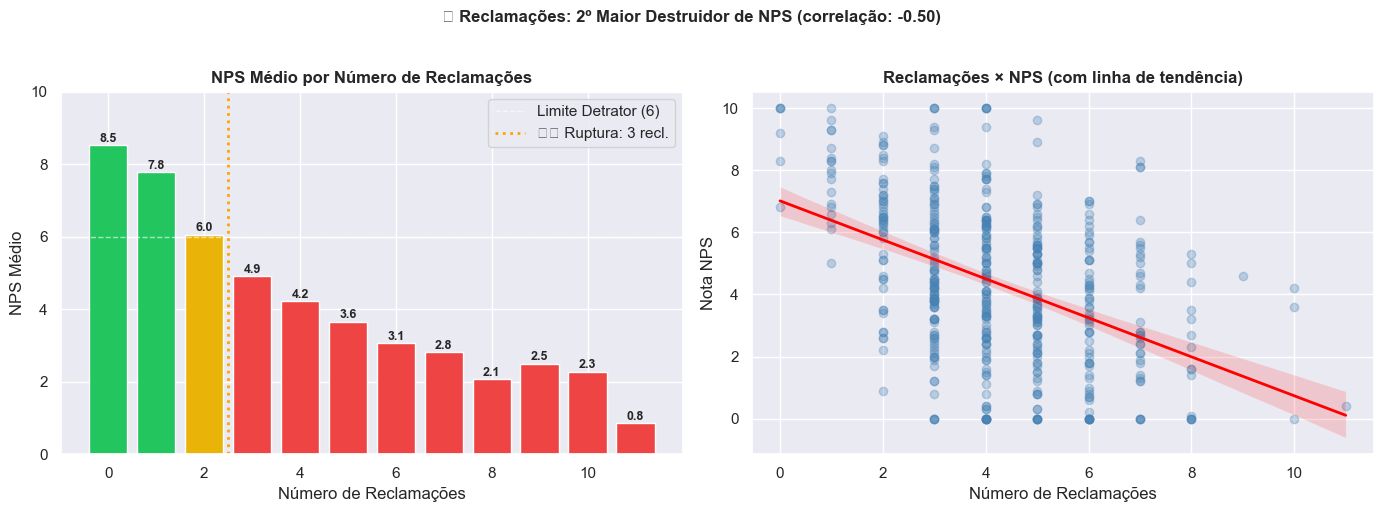

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Barras com ponto de ruptura
x_recl = nps_por_reclamacao.index
y_recl = nps_por_reclamacao['media']
cores_recl = ['#22c55e' if v >= 7 else ('#eab308' if v >= 5 else '#ef4444') for v in y_recl]

axes[0].bar(x_recl, y_recl, color=cores_recl, edgecolor='white')
axes[0].axhline(LIMITE_DETRATOR, color='white', linestyle='--', linewidth=1, alpha=0.6,
                label=f'Limite Detrator ({LIMITE_DETRATOR})')
if ponto_ruptura_recl is not None:
    axes[0].axvline(ponto_ruptura_recl - 0.5, color='orange', linestyle=':', linewidth=2,
                   label=f'⚠️ Ruptura: {ponto_ruptura_recl} recl.')
for xi, yi in zip(x_recl, y_recl):
    axes[0].text(xi, yi + 0.1, f'{yi:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('NPS Médio por Número de Reclamações', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Reclamações')
axes[0].set_ylabel('NPS Médio')
axes[0].set_ylim(0, 10)
axes[0].legend()

# Gráfico B: Scatter com linha de tendência
sns.regplot(
    data=df.sample(500, random_state=42),
    x='complaints_count', y='nps_score',
    scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Reclamações × NPS (com linha de tendência)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Reclamações')
axes[1].set_ylabel('Nota NPS')

corr_recl = correlacoes.get('complaints_count', 0)
plt.suptitle(f'📋 Reclamações: 2º Maior Destruidor de NPS (correlação: {corr_recl:.2f})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/05_reclamacoes_vs_nps.png', dpi=150, bbox_inches='tight')
plt.show()

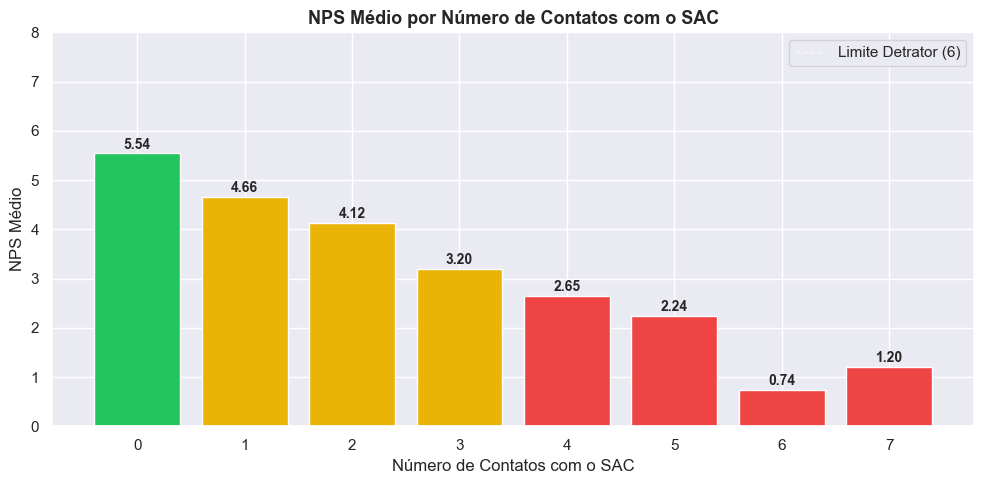


💡 INSIGHT DE NEGÓCIO:
Clientes sem contato com o SAC têm NPS 5.54.
Com 7 ou mais contatos, o NPS cai para 1.20.


In [19]:
# ── ETAPA: ATENDIMENTO — Contatos com SAC ───────────────────
nps_por_contatos = df.groupby('customer_service_contacts')['nps_score'].mean().round(2)

# ✅ Ponto de ruptura do SAC calculado dinamicamente
ponto_ruptura_sac = nps_por_contatos[nps_por_contatos < 3].index.min()
nps_0_contatos    = nps_por_contatos.get(0, None)
nps_max_contatos  = nps_por_contatos.iloc[-1]
n_max_contatos    = nps_por_contatos.index[-1]

plt.figure(figsize=(10, 5))
cores_sac = ['#22c55e' if v >= 5 else ('#eab308' if v >= 3 else '#ef4444')
             for v in nps_por_contatos.values]
bars = plt.bar(nps_por_contatos.index, nps_por_contatos.values, color=cores_sac, edgecolor='white')
plt.axhline(LIMITE_DETRATOR, color='white', linestyle='--', linewidth=1, alpha=0.6, label=f'Limite Detrator ({LIMITE_DETRATOR})')
for bar, val in zip(bars, nps_por_contatos.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}',
             ha='center', fontsize=10, fontweight='bold')
plt.title('NPS Médio por Número de Contatos com o SAC', fontsize=13, fontweight='bold')
plt.xlabel('Número de Contatos com o SAC')
plt.ylabel('NPS Médio')
plt.ylim(0, 8)
plt.xticks(nps_por_contatos.index)
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/06_sac_vs_nps.png', dpi=150, bbox_inches='tight')
plt.show()

# ✅ Tudo calculado — nenhum número hardcoded
print('\n💡 INSIGHT DE NEGÓCIO:')
if nps_0_contatos is not None:
    print(f'Clientes sem contato com o SAC têm NPS {nps_0_contatos:.2f}.')
print(f'Com {n_max_contatos} ou mais contatos, o NPS cai para {nps_max_contatos:.2f}.')


---
## 7. Perfil do Cliente: Detrator vs Promotor

> 🧠 **Aprenda:** filtrar um DataFrame é como usar o filtro do Excel.
> `df[df['coluna'] == 'valor']` retorna só as linhas que satisfazem a condição.

In [20]:
# Filtra os dois grupos extremos
detratores = df[df['nps_categoria'] == 'Detrator']
promotores  = df[df['nps_categoria'] == 'Promotor']

variaveis_jornada = {
    'delivery_delay_days':        'Dias de Atraso na Entrega',
    'complaints_count':           'Número de Reclamações',
    'customer_service_contacts':  'Contatos com o SAC',
    'resolution_time_days':       'Dias para Resolver Problemas',
    'delivery_time_days':         'Tempo de Entrega (dias)',
    'order_value':                'Valor do Pedido (R$)',
    'csat_internal_score':        'Score Interno de Satisfação'
}

print('=' * 68)
print(f'{"Variável":35s} {"Detrator":>12s} {"Promotor":>12s} {"Diferença":>8s}')
print('-' * 68)

# ✅ Todos os valores são calculados a partir dos grupos filtrados
for col, nome in variaveis_jornada.items():
    med_det = detratores[col].mean()
    med_pro = promotores[col].mean()
    diff    = med_det - med_pro
    emoji   = '🔴' if abs(diff) > 1 else ('🟡' if abs(diff) > 0.3 else '⚪')
    print(f'{nome[:35]:35s} {med_det:>12.2f} {med_pro:>12.2f} {diff:>+8.2f} {emoji}')

print('=' * 68)
print(f'\nBase: {len(detratores)} detratores | {len(promotores)} promotores')

Variável                                Detrator     Promotor Diferença
--------------------------------------------------------------------
Dias de Atraso na Entrega                   2.53         0.76    +1.78 🔴
Número de Reclamações                       4.62         2.39    +2.23 🔴
Contatos com o SAC                          1.69         0.78    +0.91 🟡
Dias para Resolver Problemas                5.79         4.10    +1.69 🔴
Tempo de Entrega (dias)                     8.00         8.04    -0.05 ⚪
Valor do Pedido (R$)                      428.99       453.69   -24.70 🔴
Score Interno de Satisfação                 2.34         5.60    -3.26 🔴

Base: 1851 detratores | 201 promotores


C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\3595082043.py:33: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\3595082043.py:33: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\3595082043.py:34: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/07_perfil_detrator_promotor.png', dpi=150, bbox_inches='tight')
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\3595082043.py:34: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/07_perfil_detrator_promotor.png', dpi=150, bbox_inches='tight')
C:\Users\Abner&Luiza\AppData\Roaming\Python\Python314\

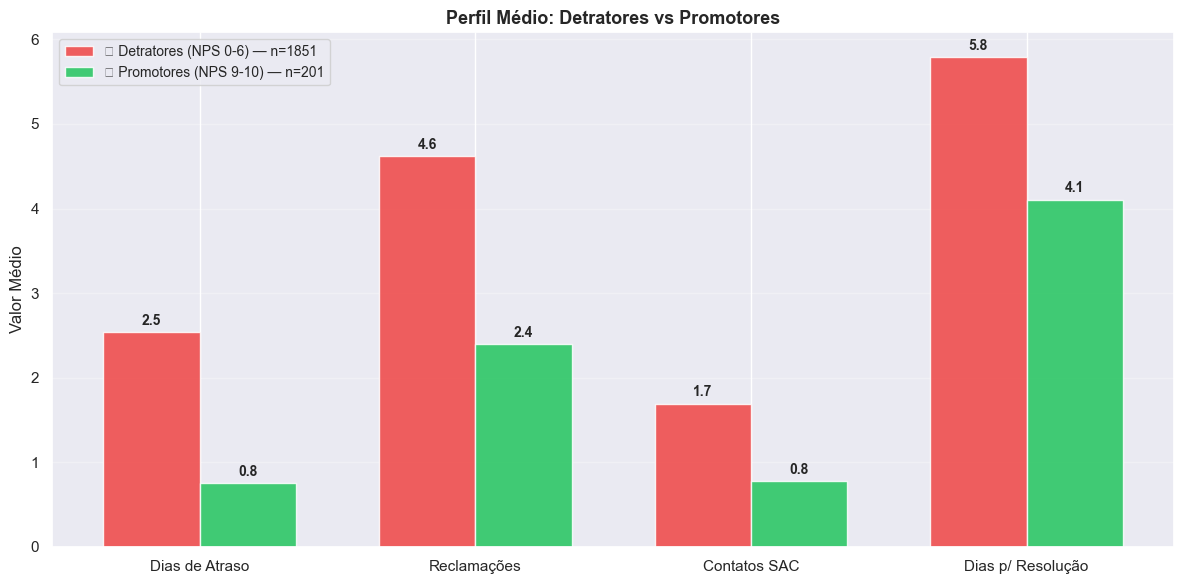

In [21]:
vars_plot   = ['delivery_delay_days', 'complaints_count',
               'customer_service_contacts', 'resolution_time_days']
nomes_plot  = ['Dias de Atraso', 'Reclamações', 'Contatos SAC', 'Dias p/ Resolução']

# ✅ Médias calculadas dos grupos — não escritas na mão
medias_det = [detratores[v].mean() for v in vars_plot]
medias_pro = [promotores[v].mean() for v in vars_plot]

x = np.arange(len(vars_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, medias_det, width,
               label=f'🔴 Detratores (NPS 0-6) — n={len(detratores)}',
               color='#ef4444', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, medias_pro, width,
               label=f'🟢 Promotores (NPS 9-10) — n={len(promotores)}',
               color='#22c55e', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Perfil Médio: Detratores vs Promotores', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nomes_plot, fontsize=11)
ax.set_ylabel('Valor Médio')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/07_perfil_detrator_promotor.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Análise por Região

In [22]:
nps_regiao = df.groupby('customer_region')['nps_score'].agg(
    media='mean', mediana='median', clientes='count', desvio='std'
).round(2).sort_values('media')

# ✅ Calculamos amplitude e extremos — sem hardcode
amplitude      = nps_regiao['media'].max() - nps_regiao['media'].min()
regiao_pior    = nps_regiao['media'].idxmin()
regiao_melhor  = nps_regiao['media'].idxmax()
nps_pior       = nps_regiao['media'].min()
nps_melhor     = nps_regiao['media'].max()

print('🗺️  NPS POR REGIÃO:')
print(nps_regiao.to_string())
print()
print(f'Região com menor NPS: {regiao_pior} ({nps_pior:.2f})')
print(f'Região com maior NPS: {regiao_melhor} ({nps_melhor:.2f})')
print(f'Amplitude entre regiões: {amplitude:.2f} pontos')
print()
print('💡 CONCLUSÃO:')
if amplitude < 1:
    print(f'As regiões têm NPS muito parecido (amplitude de apenas {amplitude:.2f} ponto).')
    print('O problema é SISTÊMICO — afeta toda a operação, não uma região específica.')
else:
    print(f'Há variação regional relevante de {amplitude:.2f} pontos — vale investigar causas regionais.')

🗺️  NPS POR REGIÃO:
                 media  mediana  clientes  desvio
customer_region                                  
Centro-Oeste      4.21     4.20       468    2.63
Sudeste           4.37     4.30       520    2.49
Norte             4.38     4.50       506    2.49
Nordeste          4.42     4.50       485    2.43
Sul               4.49     4.50       521    2.52

Região com menor NPS: Centro-Oeste (4.21)
Região com maior NPS: Sul (4.49)
Amplitude entre regiões: 0.28 pontos

💡 CONCLUSÃO:
As regiões têm NPS muito parecido (amplitude de apenas 0.28 ponto).
O problema é SISTÊMICO — afeta toda a operação, não uma região específica.


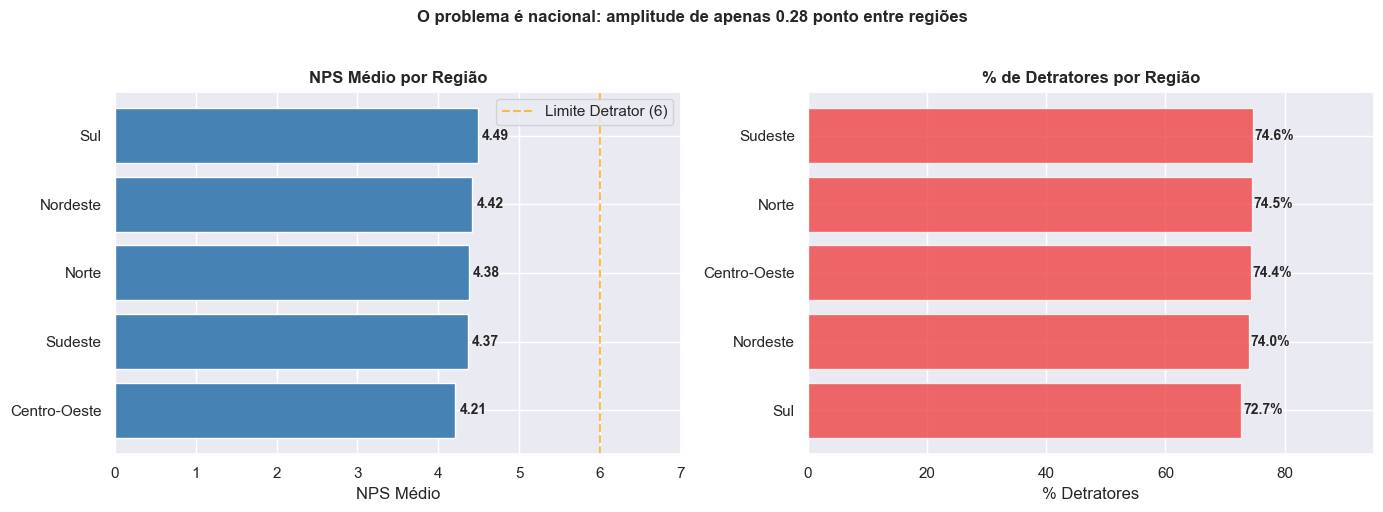

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: NPS médio por região
regioes = nps_regiao.index
medias_reg = nps_regiao['media']

axes[0].barh(regioes, medias_reg, color='steelblue', edgecolor='white')
axes[0].axvline(LIMITE_DETRATOR, color='orange', linestyle='--', alpha=0.7,
                label=f'Limite Detrator ({LIMITE_DETRATOR})')
for i, (reg, val) in enumerate(zip(regioes, medias_reg)):
    axes[0].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('NPS Médio por Região', fontsize=12, fontweight='bold')
axes[0].set_xlabel('NPS Médio')
axes[0].set_xlim(0, 7)
axes[0].legend()

# Gráfico B: % de detratores por região — calculado dos dados
pct_detrator_regiao = (
    df.groupby('customer_region')['nps_categoria']
    .apply(lambda x: (x == 'Detrator').mean() * 100)
    .sort_values(ascending=True)
)
axes[1].barh(pct_detrator_regiao.index, pct_detrator_regiao.values,
             color='#ef4444', alpha=0.8, edgecolor='white')
for i, (reg, val) in enumerate(zip(pct_detrator_regiao.index, pct_detrator_regiao.values)):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_title('% de Detratores por Região', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% Detratores')
axes[1].set_xlim(0, 95)

plt.suptitle(f'O problema é nacional: amplitude de apenas {amplitude:.2f} ponto entre regiões',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS\08_nps_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Recompra: o indicador que valida tudo

> 🧠 **Aprenda:** quando dois indicadores independentes apontam para a mesma direção (NPS alto + recompra alta), o achado é mais confiável. Isso se chama **triangulação de evidências**.

In [24]:
# ✅ Tudo calculado dinamicamente
nps_recompra   = df.groupby('repeat_purchase_30d')['nps_score'].mean().round(2)
taxa_recompra  = df.groupby('nps_categoria')['repeat_purchase_30d'].mean() * 100

nps_recomprou      = nps_recompra.get(1, None)
nps_nao_recomprou  = nps_recompra.get(0, None)
diferenca_recompra = nps_recomprou - nps_nao_recomprou

print('🔄 NPS MÉDIO POR STATUS DE RECOMPRA:')
print(f'  Não recomprou: NPS = {nps_nao_recomprou:.2f}')
print(f'  Recomprou:     NPS = {nps_recomprou:.2f}')
print(f'  Diferença:     +{diferenca_recompra:.2f} pontos')
print()
print('📈 TAXA DE RECOMPRA POR CATEGORIA NPS:')
for cat in ['Promotor', 'Neutro', 'Detrator']:
    taxa = taxa_recompra.get(cat, 0)
    print(f'  {cat:10s}: {taxa:.1f}% voltaram a comprar em 30 dias')
print()
print('💡 INSIGHT DE NEGÓCIO:')
print(f'Quem recomprou tem NPS de {nps_recomprou:.2f} — praticamente promotor!')
corr_recompra = correlacoes.get('repeat_purchase_30d', 0)
print(f'A correlação entre recompra e NPS é +{corr_recompra:.2f} — das mais fortes da base.')
print('Satisfação e lealdade são duas faces da mesma moeda.')

🔄 NPS MÉDIO POR STATUS DE RECOMPRA:
  Não recomprou: NPS = 3.94
  Recomprou:     NPS = 9.01
  Diferença:     +5.07 pontos

📈 TAXA DE RECOMPRA POR CATEGORIA NPS:
  Promotor  : 100.0% voltaram a comprar em 30 dias
  Neutro    : 3.8% voltaram a comprar em 30 dias
  Detrator  : 0.0% voltaram a comprar em 30 dias

💡 INSIGHT DE NEGÓCIO:
Quem recomprou tem NPS de 9.01 — praticamente promotor!
A correlação entre recompra e NPS é +0.57 — das mais fortes da base.
Satisfação e lealdade são duas faces da mesma moeda.


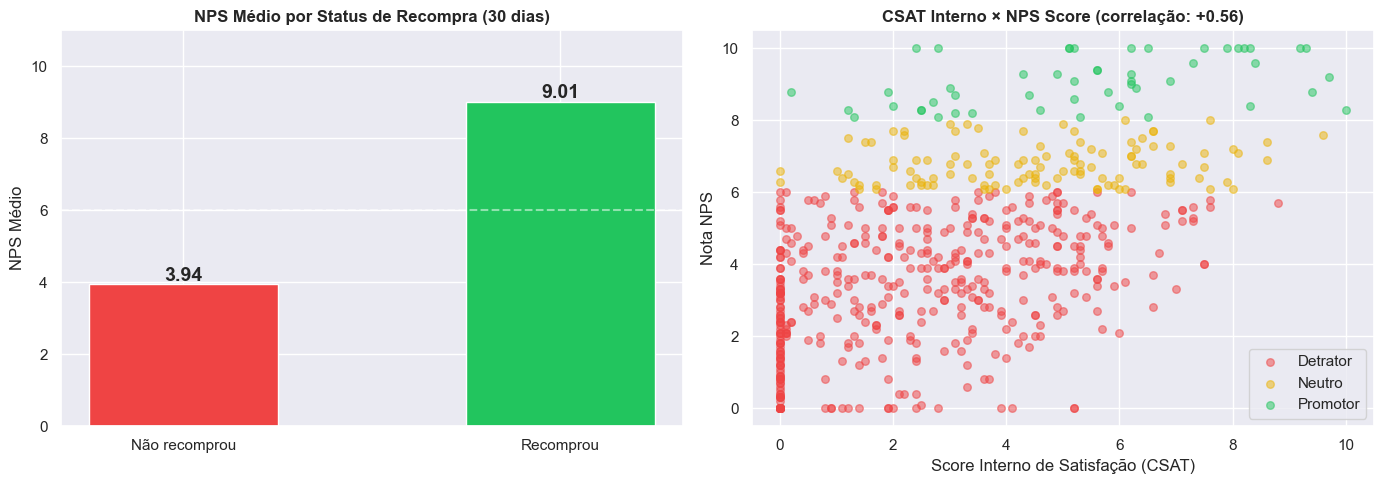

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Recompra vs NPS
labels_rec = ['Não recomprou', 'Recomprou']
vals_rec   = [nps_nao_recomprou, nps_recomprou]
cores_rec  = ['#ef4444', '#22c55e']

bars = axes[0].bar(labels_rec, vals_rec, color=cores_rec, edgecolor='white', width=0.5)
for bar, val in zip(bars, vals_rec):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                f'{val:.2f}', ha='center', fontsize=14, fontweight='bold')
axes[0].set_title(f'NPS Médio por Status de Recompra (30 dias)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('NPS Médio')
axes[0].set_ylim(0, 11)
axes[0].axhline(LIMITE_DETRATOR, color='white', linestyle='--', alpha=0.5)

# Gráfico B: CSAT vs NPS
cats_cores = {'Detrator': '#ef4444', 'Neutro': '#eab308', 'Promotor': '#22c55e'}
amostra = df.sample(600, random_state=42)
for cat, cor in cats_cores.items():
    subset = amostra[amostra['nps_categoria'] == cat]
    axes[1].scatter(subset['csat_internal_score'], subset['nps_score'],
                   c=cor, label=cat, alpha=0.5, s=30)
corr_csat = correlacoes.get('csat_internal_score', 0)
axes[1].set_title(f'CSAT Interno × NPS Score (correlação: {corr_csat:+.2f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score Interno de Satisfação (CSAT)')
axes[1].set_ylabel('Nota NPS')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/09_recompra_csat_nps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Resumo Final dos Insights de Negócio

In [25]:
# ✅ PAINEL FINAL — 100% dinâmico
# Todos os números são recalculados toda vez que você rodar esta célula

corr_atraso   = correlacoes.get('delivery_delay_days', 0)
corr_recl     = correlacoes.get('complaints_count', 0)
corr_sac      = correlacoes.get('customer_service_contacts', 0)
corr_recompra = correlacoes.get('repeat_purchase_30d', 0)

n_detratores  = contagem.get('Detrator', 0)
n_promotores  = contagem.get('Promotor', 0)
pct_det       = pct.get('Detrator', 0)
pct_pro       = pct.get('Promotor', 0)

print()
print('=' * 72)
print('  📋 SUMÁRIO EXECUTIVO — ANÁLISE DE NPS')
print('=' * 72)
print()
print('  SITUAÇÃO ATUAL:')
print(f'  → NPS médio: {nps_medio:.2f}  |  NPS da empresa: {nps_empresa:.0f}%  (referência saudável: +30 a +60)')
print(f'  → {pct_det:.0f}% dos clientes são Detratores ({n_detratores} de {n_linhas})')
print(f'  → Apenas {pct_pro:.0f}% são Promotores ({n_promotores} clientes)')
print()
print('  PRINCIPAIS FATORES QUE DESTROEM O NPS:')
print()
print(f'  🔴 1. ATRASO NA ENTREGA (correlação: {corr_atraso:.2f}) — CRÍTICO')
for faixa in ordem_faixas:
    print(f'     - {faixa}: NPS {nps_por_atraso[faixa]:.2f}')
print(f'     → Ação: alertas automáticos quando previsão superar 7 dias')
print()
print(f'  🔴 2. VOLUME DE RECLAMAÇÕES (correlação: {corr_recl:.2f}) — CRÍTICO')
print(f'     - 0 reclamações:  NPS {nps_media_por_recl.get(0, 0):.2f}')
if ponto_ruptura_recl is not None:
    print(f'     - {ponto_ruptura_recl} reclamações:  NPS {nps_media_por_recl.get(ponto_ruptura_recl, 0):.2f}  ← ponto de ruptura')
print(f'     → Ação: identificar as causas raiz das reclamações')
print()
print(f'  🟠 3. CONTATOS COM SAC (correlação: {corr_sac:.2f}) — RELEVANTE')
if nps_0_contatos is not None:
    print(f'     - 0 contatos:  NPS {nps_0_contatos:.2f}')
print(f'     - {n_max_contatos}+ contatos: NPS {nps_max_contatos:.2f}')
print(f'     → Ação: resolver o problema no primeiro contato (First Call Resolution)')
print()

# Identifica variáveis com correlação irrelevante (próxima de zero)
irrelevantes = corr_filtrada[abs(corr_filtrada) < 0.05].index.tolist()
if irrelevantes:
    print('  O QUE NÃO IMPACTA (correlação < 0.05):')
    print(f'  ⚪ {", ".join(irrelevantes)}')
    print()

print('  CONCLUSÃO PARA O NEGÓCIO:')
print('  O cliente não reclama do preço ou da forma de pagamento.')
print('  Ele quer receber no prazo e ser bem atendido quando algo dá errado.')
print(f'  Atacar atraso e reclamações poderia reverter a maioria dos {n_detratores} detratores.')
print()
print('=' * 72)


  📋 SUMÁRIO EXECUTIVO — ANÁLISE DE NPS

  SITUAÇÃO ATUAL:
  → NPS médio: 4.38  |  NPS da empresa: -66%  (referência saudável: +30 a +60)
  → 74% dos clientes são Detratores (1851 de 2500)
  → Apenas 8% são Promotores (201 clientes)

  PRINCIPAIS FATORES QUE DESTROEM O NPS:

  🔴 1. ATRASO NA ENTREGA (correlação: -0.60) — CRÍTICO
     - Sem atraso: NPS 6.86
     - 1-3 dias: NPS 4.58
     - 4-7 dias: NPS 2.01
     - 8+ dias: NPS 0.00
     → Ação: alertas automáticos quando previsão superar 7 dias

  🔴 2. VOLUME DE RECLAMAÇÕES (correlação: -0.50) — CRÍTICO
     - 0 reclamações:  NPS 8.52
     - 3 reclamações:  NPS 4.91  ← ponto de ruptura
     → Ação: identificar as causas raiz das reclamações

  🟠 3. CONTATOS COM SAC (correlação: -0.35) — RELEVANTE
     - 0 contatos:  NPS 5.54
     - 7+ contatos: NPS 1.20
     → Ação: resolver o problema no primeiro contato (First Call Resolution)

  O QUE NÃO IMPACTA (correlação < 0.05):
  ⚪ freight_value, customer_age, customer_tenure_months, delivery_

---

## ✅ Próximos passos

1. **Modelo preditivo** (`02_modelo_preditivo.ipynb`) — classificar risco de Detrator antes da pesquisa
2. **Apresentação de slides** — storytelling para gestores
3. **Vídeo executivo** — até 5 minutos

---

> 📚 **Conceito-chave aprendido aqui:**
> Nunca escreva resultados na mão dentro do código. Sempre calcule a partir dos dados.
> Se a base mudar amanhã, rode o notebook de novo — e todos os insights se atualizam sozinhos.

---
## 11. Reclamações têm a ver com o atraso na entrega?

A hipótese aqui é intuitiva: quem esperou mais tempo, reclamou mais.
Vamos verificar se os dados confirmam isso.

> 🧠 **Aprenda:** quando queremos saber se **dois fatores andam juntos** (ex: atraso e reclamação),
> usamos correlação. Quando queremos ver **como a média de um muda conforme o outro cresce**,
> usamos `groupby()`. Aqui vamos usar os dois para ter uma visão completa.

In [26]:
# Correlação direta entre atraso e número de reclamações
corr_atraso_recl = df['delivery_delay_days'].corr(df['complaints_count'])

# Média de reclamações por faixa de atraso
recl_por_atraso = df.groupby('faixa_atraso', observed=True).agg(
    reclamacoes_media  = ('complaints_count', 'mean'),
    nps_media          = ('nps_score', 'mean'),
    clientes           = ('nps_score', 'count')
).round(2)

# Variação de reclamações entre a faixa mais leve e a mais grave
recl_sem_atraso = recl_por_atraso['reclamacoes_media']['Sem atraso']
recl_maior      = recl_por_atraso['reclamacoes_media'].max()
faixa_maior     = recl_por_atraso['reclamacoes_media'].idxmax()
aumento_recl    = recl_maior - recl_sem_atraso
pct_aumento     = aumento_recl / recl_sem_atraso * 100

print('🔗 CORRELAÇÃO: Atraso na Entrega × Número de Reclamações')
print(f'   Coeficiente: {corr_atraso_recl:.3f}')
if corr_atraso_recl > 0.3:
    print('   → Correlação positiva moderada a forte: mais atraso = mais reclamações')
elif corr_atraso_recl > 0.1:
    print('   → Correlação positiva fraca: o atraso contribui para reclamações, mas não é o único fator')
else:
    print('   → Correlação muito fraca: reclamações têm outras causas além do atraso')
print()
print('📊 MÉDIA DE RECLAMAÇÕES POR FAIXA DE ATRASO:')
print('-' * 60)
print(f'{"Faixa":15s}  {"Reclamações (média)":>20s}  {"NPS médio":>12s}  {"Clientes":>10s}')
print('-' * 60)
for faixa, row in recl_por_atraso.iterrows():
    emoji = '🟢' if row['nps_media'] > 6 else ('🟡' if row['nps_media'] > 3 else '🔴')
    print(f'{str(faixa):15s}  {row["reclamacoes_media"]:>20.2f}  {row["nps_media"]:>12.2f}  {int(row["clientes"]):>10d}  {emoji}')
print('-' * 60)
print()
print(f'💡 INSIGHT: Clientes sem atraso têm em média {recl_sem_atraso:.2f} reclamações.')
print(f'   Na faixa "{faixa_maior}", a média sobe para {recl_maior:.2f} reclamações')
print(f'   — um aumento de {aumento_recl:.2f} reclamações ({pct_aumento:.0f}% a mais).')
print()
print('   ⚠️  Isso significa que o atraso não apenas derruba o NPS diretamente,')
print('   mas também DISPARA reclamações, que por sua vez derrubam o NPS ainda mais.')
print('   É um efeito em cascata: atraso → reclamações → NPS baixo.')

🔗 CORRELAÇÃO: Atraso na Entrega × Número de Reclamações
   Coeficiente: 0.190
   → Correlação positiva fraca: o atraso contribui para reclamações, mas não é o único fator

📊 MÉDIA DE RECLAMAÇÕES POR FAIXA DE ATRASO:
------------------------------------------------------------
Faixa             Reclamações (média)     NPS médio    Clientes
------------------------------------------------------------
Sem atraso                       2.96          6.86         277  🟢
1-3 dias                         4.24          4.58        1786  🟡
4-7 dias                         4.56          2.01         434  🔴
8+ dias                          4.33          0.00           3  🔴
------------------------------------------------------------

💡 INSIGHT: Clientes sem atraso têm em média 2.96 reclamações.
   Na faixa "4-7 dias", a média sobe para 4.56 reclamações
   — um aumento de 1.60 reclamações (54% a mais).

   ⚠️  Isso significa que o atraso não apenas derruba o NPS diretamente,
   mas também DISPARA r

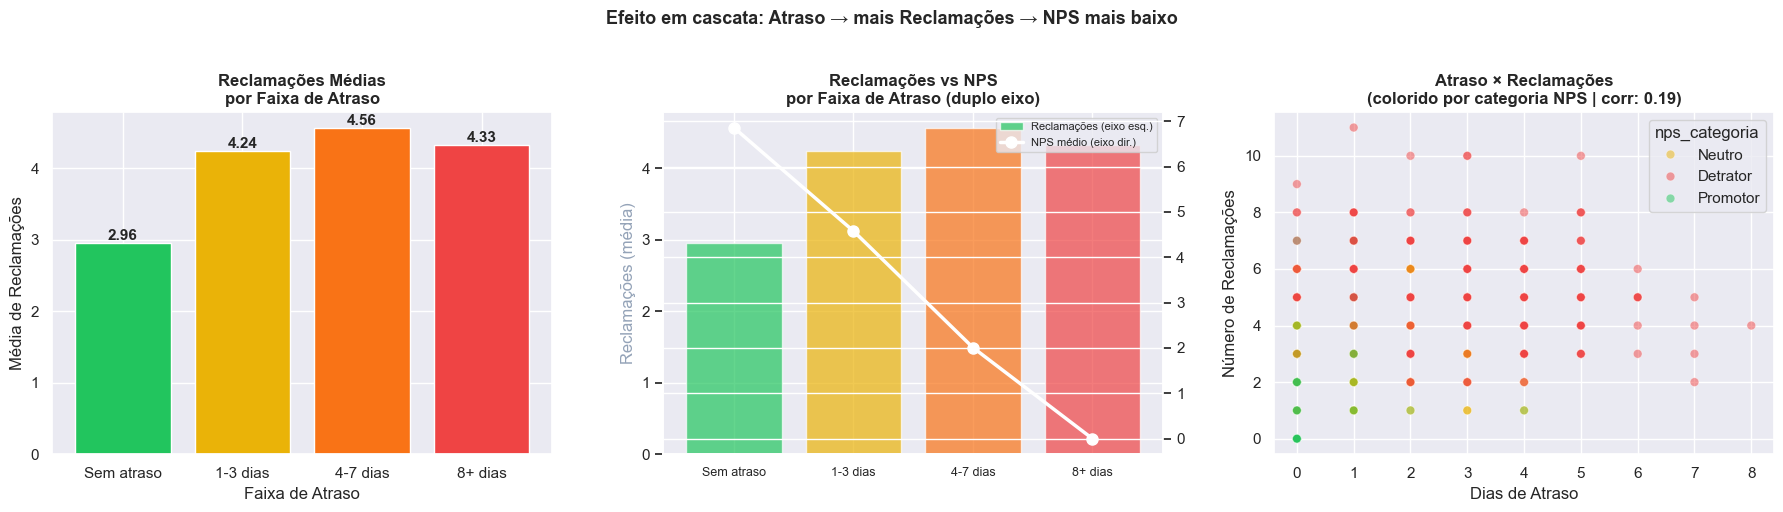


💡 COMO LER O GRÁFICO DO MEIO (duplo eixo):
As barras mostram o volume de reclamações (eixo esquerdo).
A linha branca mostra o NPS médio (eixo direito).
Quando as barras sobem (mais reclamações), a linha cai (NPS menor).


In [27]:
ordem_faixas = ['Sem atraso', '1-3 dias', '4-7 dias', '8+ dias']
cores_faixa  = ['#22c55e', '#eab308', '#f97316', '#ef4444']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Reclamações médias por faixa de atraso
vals_recl = [recl_por_atraso.loc[f, 'reclamacoes_media'] for f in ordem_faixas]
axes[0].bar(ordem_faixas, vals_recl, color=cores_faixa, edgecolor='white')
for i, val in enumerate(vals_recl):
    axes[0].text(i, val + 0.04, f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Reclamações Médias\npor Faixa de Atraso', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Faixa de Atraso')
axes[0].set_ylabel('Média de Reclamações')

# Gráfico B: Duplo eixo — reclamações e NPS por faixa
# Mostra visualmente como os dois sobem/descem juntos
ax2 = axes[1]
ax2b = ax2.twinx()  # cria um segundo eixo Y no mesmo gráfico

vals_nps_faixa = [recl_por_atraso.loc[f, 'nps_media'] for f in ordem_faixas]
x = range(len(ordem_faixas))

bars = ax2.bar(x, vals_recl, color=cores_faixa, alpha=0.7, edgecolor='white', label='Reclamações (eixo esq.)')
linha = ax2b.plot(x, vals_nps_faixa, color='white', marker='o', linewidth=2.5,
                  markersize=8, label='NPS médio (eixo dir.)')
ax2.set_xticks(x)
ax2.set_xticklabels(ordem_faixas, fontsize=9)
ax2.set_ylabel('Reclamações (média)', color='#94a3b8')
ax2b.set_ylabel('NPS Médio', color='white')
ax2.set_title('Reclamações vs NPS\npor Faixa de Atraso (duplo eixo)', fontsize=12, fontweight='bold')
linhas1, labels1 = ax2.get_legend_handles_labels()
linhas2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(linhas1 + linhas2, labels1 + labels2, loc='upper right', fontsize=8)

# Gráfico C: Scatter — atraso × reclamações (cada ponto = 1 cliente)
amostra = df.sample(600, random_state=42)
sns.scatterplot(
    data=amostra, x='delivery_delay_days', y='complaints_count',
    hue='nps_categoria',
    palette={'Detrator':'#ef4444','Neutro':'#eab308','Promotor':'#22c55e'},
    alpha=0.5, s=40, ax=axes[2]
)
axes[2].set_title(f'Atraso × Reclamações\n(colorido por categoria NPS | corr: {corr_atraso_recl:.2f})',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Dias de Atraso')
axes[2].set_ylabel('Número de Reclamações')

plt.suptitle('Efeito em cascata: Atraso → mais Reclamações → NPS mais baixo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/10_reclamacoes_vs_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 COMO LER O GRÁFICO DO MEIO (duplo eixo):')
print('As barras mostram o volume de reclamações (eixo esquerdo).')
print('A linha branca mostra o NPS médio (eixo direito).')
print('Quando as barras sobem (mais reclamações), a linha cai (NPS menor).')

---
## 12. A logística de entrega varia por região? Isso afeta o NPS?

Queremos entender se algumas regiões sofrem mais com problemas logísticos
(mais atraso, mais tentativas de entrega) e se isso se reflete no NPS regional.

> 🧠 **Aprenda:** quando cruzamos **três variáveis ao mesmo tempo** (região, logística e NPS),
> estamos fazendo uma **análise multivariada**. A forma mais clara de visualizar isso
> é com uma tabela-resumo ou um gráfico de barras agrupadas.

In [28]:
# Resumo logístico por região — tudo calculado dos dados
log_regiao = df.groupby('customer_region').agg(
    atraso_medio       = ('delivery_delay_days',  'mean'),
    tempo_entrega_medio= ('delivery_time_days',    'mean'),
    tentativas_media   = ('delivery_attempts',     'mean'),
    pct_sem_atraso     = ('delivery_delay_days',   lambda x: (x == 0).mean() * 100),
    nps_medio          = ('nps_score',             'mean'),
    total_clientes     = ('nps_score',             'count')
).round(2).sort_values('atraso_medio', ascending=False)

# Correlação entre atraso e NPS calculada dentro de cada região
corr_por_regiao = df.groupby('customer_region').apply(
    lambda g: g['delivery_delay_days'].corr(g['nps_score'])
).round(3)

# Identifica a região com pior e melhor logística
regiao_mais_atraso  = log_regiao['atraso_medio'].idxmax()
regiao_menos_atraso = log_regiao['atraso_medio'].idxmin()
diff_atraso         = log_regiao['atraso_medio'].max() - log_regiao['atraso_medio'].min()
diff_nps_regiao     = log_regiao['nps_medio'].max() - log_regiao['nps_medio'].min()

print('🗺️  PERFIL LOGÍSTICO POR REGIÃO:')
print('=' * 80)
print(f'{"Região":15s}  {"Atraso(dias)":>12s}  {"Entrega(dias)":>14s}  {"% Sem Atraso":>13s}  {"NPS":>8s}')
print('-' * 80)
for regiao, row in log_regiao.iterrows():
    corr_r = corr_por_regiao.get(regiao, 0)
    print(f'{regiao:15s}  {row["atraso_medio"]:>12.2f}  {row["tempo_entrega_medio"]:>14.2f}  '
          f'{row["pct_sem_atraso"]:>13.1f}%  {row["nps_medio"]:>8.2f}')
print('=' * 80)
print()
print(f'Maior atraso médio:  {regiao_mais_atraso} ({log_regiao.loc[regiao_mais_atraso,"atraso_medio"]:.2f} dias)')
print(f'Menor atraso médio:  {regiao_menos_atraso} ({log_regiao.loc[regiao_menos_atraso,"atraso_medio"]:.2f} dias)')
print(f'Diferença entre regiões: {diff_atraso:.2f} dias de atraso  |  {diff_nps_regiao:.2f} pontos de NPS')
print()
print('🔗 CORRELAÇÃO ATRASO × NPS DENTRO DE CADA REGIÃO:')
for regiao, corr_val in corr_por_regiao.sort_values().items():
    forca = 'forte' if abs(corr_val) > 0.5 else ('moderada' if abs(corr_val) > 0.3 else 'fraca')
    print(f'  {regiao:15s}: {corr_val:.3f}  ({forca})')
print()
if diff_atraso < 0.5:
    print('💡 CONCLUSÃO: A logística é muito similar entre regiões.')
    print('   O atraso destrói o NPS em TODAS as regiões com a mesma intensidade.')
    print('   Isso reforça que o problema é de processo — não de distribuição geográfica.')
else:
    print(f'💡 CONCLUSÃO: Há diferença logística relevante entre regiões ({diff_atraso:.2f} dias).')
    print(f'   {regiao_mais_atraso} é a região mais afetada — merece atenção prioritária.')

🗺️  PERFIL LOGÍSTICO POR REGIÃO:
Região           Atraso(dias)   Entrega(dias)   % Sem Atraso       NPS
--------------------------------------------------------------------------------
Centro-Oeste             2.22            7.91           12.4%      4.21
Sudeste                  2.22            8.20            9.0%      4.37
Nordeste                 2.19            8.16            9.9%      4.42
Sul                      2.17            8.07           12.1%      4.49
Norte                    2.14            7.76           12.1%      4.38

Maior atraso médio:  Centro-Oeste (2.22 dias)
Menor atraso médio:  Norte (2.14 dias)
Diferença entre regiões: 0.08 dias de atraso  |  0.28 pontos de NPS

🔗 CORRELAÇÃO ATRASO × NPS DENTRO DE CADA REGIÃO:
  Nordeste       : -0.615  (forte)
  Sul            : -0.610  (forte)
  Norte          : -0.608  (forte)
  Centro-Oeste   : -0.597  (forte)
  Sudeste        : -0.558  (forte)

💡 CONCLUSÃO: A logística é muito similar entre regiões.
   O atraso destrói

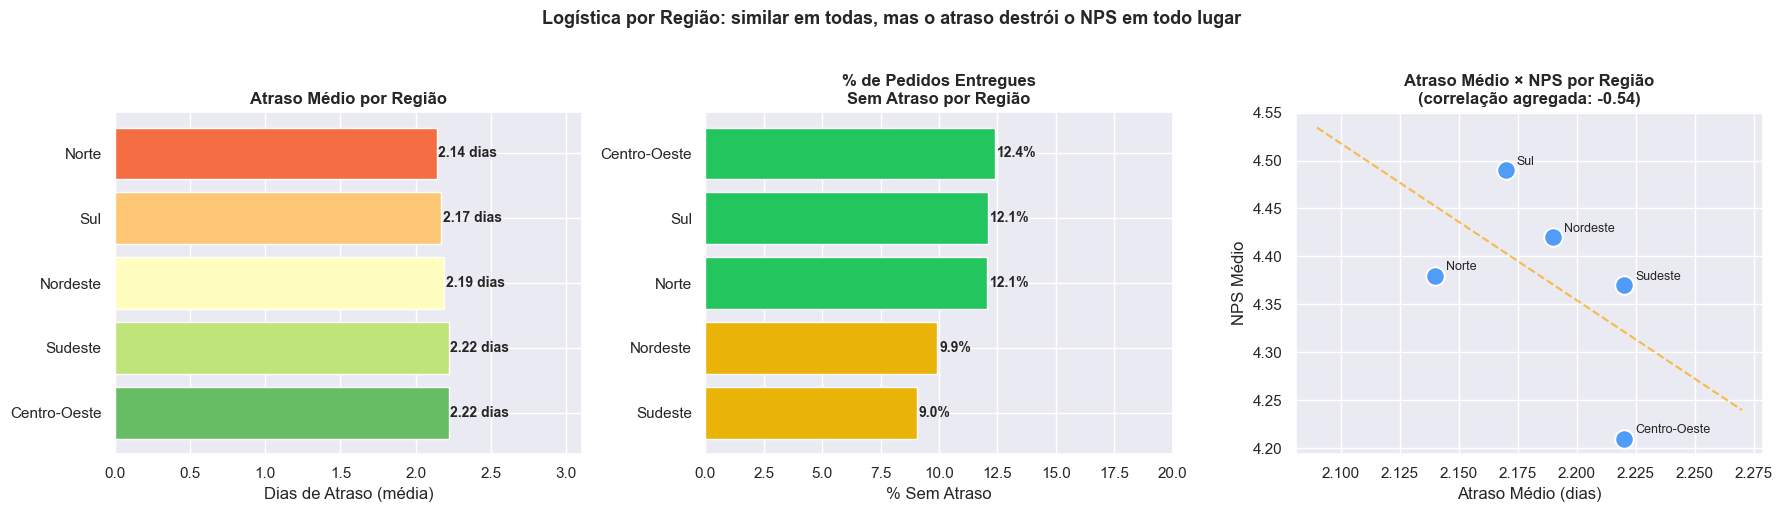


💡 COMO LER O GRÁFICO DA DIREITA:
Cada ponto é uma região. Quanto mais à direita = mais atraso.
Quanto mais abaixo = NPS mais baixo.
A linha tracejada mostra a tendência: mais atraso → NPS menor, em qualquer região.


In [29]:
regioes_ord = log_regiao.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Atraso médio por região
cores_reg = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(regioes_ord)))
bars_a = axes[0].barh(regioes_ord, log_regiao.loc[regioes_ord,'atraso_medio'],
                      color=cores_reg, edgecolor='white')
for bar, val in zip(bars_a, log_regiao.loc[regioes_ord,'atraso_medio']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f} dias', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Atraso Médio por Região', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dias de Atraso (média)')
axes[0].set_xlim(0, log_regiao['atraso_medio'].max() * 1.4)

# Gráfico B: % de pedidos sem atraso por região
pct_sem = log_regiao.loc[regioes_ord, 'pct_sem_atraso'].sort_values()
cores_pct = ['#22c55e' if v > 12 else ('#eab308' if v > 9 else '#ef4444') for v in pct_sem]
bars_b = axes[1].barh(pct_sem.index, pct_sem.values, color=cores_pct, edgecolor='white')
for bar, val in zip(bars_b, pct_sem.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_title('% de Pedidos Entregues\nSem Atraso por Região', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% Sem Atraso')
axes[1].set_xlim(0, 20)

# Gráfico C: NPS médio × atraso médio por região (scatter com rótulos)
for regiao in regioes_ord:
    x_val = log_regiao.loc[regiao, 'atraso_medio']
    y_val = log_regiao.loc[regiao, 'nps_medio']
    axes[2].scatter(x_val, y_val, s=180, zorder=5,
                   color='#4f9cf9', edgecolor='white', linewidth=1.5)
    axes[2].annotate(regiao, (x_val, y_val),
                    textcoords='offset points', xytext=(8, 4), fontsize=9)

# Linha de tendência geral
x_reg = log_regiao['atraso_medio'].values
y_reg = log_regiao['nps_medio'].values
z = np.polyfit(x_reg, y_reg, 1)
p = np.poly1d(z)
x_line = np.linspace(x_reg.min() - 0.05, x_reg.max() + 0.05, 50)
axes[2].plot(x_line, p(x_line), color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
corr_agg = np.corrcoef(x_reg, y_reg)[0,1]
axes[2].set_title(f'Atraso Médio × NPS por Região\n(correlação agregada: {corr_agg:.2f})',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Atraso Médio (dias)')
axes[2].set_ylabel('NPS Médio')

plt.suptitle('Logística por Região: similar em todas, mas o atraso destrói o NPS em todo lugar',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/11_logistica_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 COMO LER O GRÁFICO DA DIREITA:')
print('Cada ponto é uma região. Quanto mais à direita = mais atraso.')
print('Quanto mais abaixo = NPS mais baixo.')
print('A linha tracejada mostra a tendência: mais atraso → NPS menor, em qualquer região.')

---
## 13. O desconto influencia a nota do NPS?

A hipótese aqui é: *clientes que receberam mais desconto ficam mais satisfeitos e dão notas maiores?*

> 🧠 **Aprenda:** essa análise é importante para o negócio porque, se desconto elevasse o NPS,
> a empresa poderia usá-lo como alavanca de satisfação. Se não há relação, significa que
> o cliente valoriza **experiência** (entrega no prazo, bom atendimento) muito mais do que preço.

In [32]:
# Correlação direta
corr_desc_nps = df['discount_value'].corr(df['nps_score'])

# Faixas de desconto — limites definidos com base nos percentis reais dos dados
p25 = df['discount_value'].quantile(0.25)
p50 = df['discount_value'].quantile(0.50)
p75 = df['discount_value'].quantile(0.75)
desc_max = df['discount_value'].max()

df['faixa_desconto'] = pd.cut(
    df['discount_value'],
    bins=[0, p25, p50, p75, desc_max + 1],
    labels=[f'Baixo (até R${p25:.0f})',
            f'Médio-baixo (R${p25:.0f}–{p50:.0f})',
            f'Médio-alto (R${p50:.0f}–{p75:.0f})',
            f'Alto (acima de R${p75:.0f})'],
    include_lowest=True
)

nps_por_desconto = df.groupby('faixa_desconto', observed=True)['nps_score'].agg(
    media='mean', clientes='count'
).round(2)

desc_medio_geral  = df['discount_value'].mean()
desc_detratores   = df[df['nps_categoria'] == 'Detrator']['discount_value'].mean()
desc_promotores   = df[df['nps_categoria'] == 'Promotor']['discount_value'].mean()
diff_desc         = desc_promotores - desc_detratores

print('🏷️  DESCONTO × NPS')
print('=' * 55)
print(f'Correlação desconto × NPS: {corr_desc_nps:.3f}')
if abs(corr_desc_nps) < 0.1:
    print('→ Correlação praticamente nula: desconto NÃO explica a variação do NPS.')
elif abs(corr_desc_nps) < 0.3:
    print('→ Correlação fraca: desconto tem influência marginal no NPS.')
else:
    print('→ Correlação relevante: desconto influencia o NPS.')
print()
print('📊 NPS MÉDIO POR FAIXA DE DESCONTO (quartis dos dados):')
print(nps_por_desconto.to_string())
print()
print('💰 DESCONTO MÉDIO POR PERFIL:')
print(f'  Geral:      R$ {desc_medio_geral:.2f}')
print(f'  Detratores: R$ {desc_detratores:.2f}')
print(f'  Promotores: R$ {desc_promotores:.2f}')
print(f'  Diferença:  R$ {diff_desc:+.2f}')
print()
if abs(diff_desc) < 5:
    print('💡 CONCLUSÃO: Detratores e Promotores receberam descontos quase idênticos.')
    print('   O desconto não faz diferença para a satisfação do cliente.')
    print()
    print('   O cliente de e-commerce valoriza:')
    print('   ✅ Receber no prazo')
    print('   ✅ Ser bem atendido quando algo dá errado')
    print('   ❌ Desconto (não move o NPS)')
else:
    print(f'💡 Promotores receberam R${abs(diff_desc):.2f} {"mais" if diff_desc > 0 else "menos"} de desconto que Detratores.')

🏷️  DESCONTO × NPS
Correlação desconto × NPS: 0.025
→ Correlação praticamente nula: desconto NÃO explica a variação do NPS.

📊 NPS MÉDIO POR FAIXA DE DESCONTO (quartis dos dados):
                      media  clientes
faixa_desconto                       
Baixo (até R$9)        4.42       625
Médio-baixo (R$9–21)   4.22       625
Médio-alto (R$21–41)   4.45       625
Alto (acima de R$41)   4.43       625

💰 DESCONTO MÉDIO POR PERFIL:
  Geral:      R$ 29.75
  Detratores: R$ 29.63
  Promotores: R$ 31.67
  Diferença:  R$ +2.03

💡 CONCLUSÃO: Detratores e Promotores receberam descontos quase idênticos.
   O desconto não faz diferença para a satisfação do cliente.

   O cliente de e-commerce valoriza:
   ✅ Receber no prazo
   ✅ Ser bem atendido quando algo dá errado
   ❌ Desconto (não move o NPS)


C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\4283198310.py:56: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\4283198310.py:56: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\4283198310.py:57: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/12_desconto_vs_nps.png', dpi=150, bbox_inches='tight')
C:\Users\Abner&Luiza\AppData\Local\Temp\ipykernel_21332\4283198310.py:57: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/12_desconto_vs_nps.png', dpi=150, bbox_inches='tight')
C:\Users\Abner&Luiza\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtool

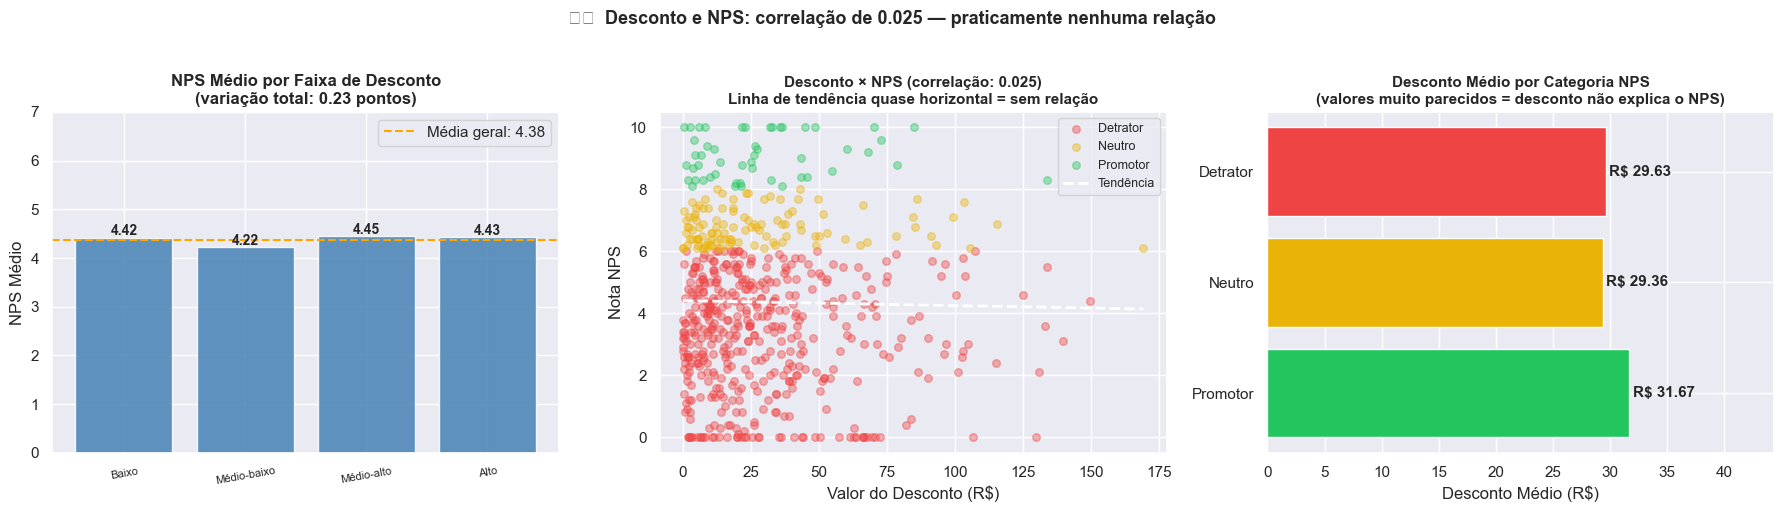


💡 COMO LER O GRÁFICO DO MEIO:
Se o desconto influenciasse o NPS, a linha de tendência seria inclinada.
Com correlação de 0.025, ela é quase horizontal — o desconto não move a agulha.


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: NPS médio por faixa de desconto
faixas_desc = nps_por_desconto.index.tolist()
vals_nps_desc = nps_por_desconto['media'].values
variacao = vals_nps_desc.max() - vals_nps_desc.min()

axes[0].bar(range(len(faixas_desc)), vals_nps_desc, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axhline(vals_nps_desc.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Média geral: {vals_nps_desc.mean():.2f}')
for i, val in enumerate(vals_nps_desc):
    axes[0].text(i, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title(f'NPS Médio por Faixa de Desconto\n(variação total: {variacao:.2f} pontos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(faixas_desc)))
axes[0].set_xticklabels([f.split('(')[0].strip() for f in faixas_desc], fontsize=8, rotation=10)
axes[0].set_ylabel('NPS Médio')
axes[0].set_ylim(0, 7)
axes[0].legend()

# Gráfico B: Scatter desconto × NPS (amostra)
amostra = df.sample(600, random_state=42)
cores_cat2 = {'Detrator': '#ef4444', 'Neutro': '#eab308', 'Promotor': '#22c55e'}
for cat, cor in cores_cat2.items():
    sub = amostra[amostra['nps_categoria'] == cat]
    axes[1].scatter(sub['discount_value'], sub['nps_score'],
                   c=cor, label=cat, alpha=0.4, s=30)
# Linha de tendência
x_desc = amostra['discount_value'].values
y_desc = amostra['nps_score'].values
z_desc = np.polyfit(x_desc, y_desc, 1)
p_desc = np.poly1d(z_desc)
x_line_desc = np.linspace(x_desc.min(), x_desc.max(), 100)
axes[1].plot(x_line_desc, p_desc(x_line_desc), color='white',
            linestyle='--', linewidth=2, label='Tendência')
axes[1].set_title(f'Desconto × NPS (correlação: {corr_desc_nps:.3f})\nLinha de tendência quase horizontal = sem relação',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor do Desconto (R$)')
axes[1].set_ylabel('Nota NPS')
axes[1].legend(fontsize=9)

# Gráfico C: Comparativo desconto médio por categoria
desc_por_cat = df.groupby('nps_categoria')['discount_value'].mean().reindex(['Promotor','Neutro','Detrator'])
cores_cat3   = ['#22c55e', '#eab308', '#ef4444']
bars_c = axes[2].barh(desc_por_cat.index, desc_por_cat.values, color=cores_cat3, edgecolor='white')
for bar, val in zip(bars_c, desc_por_cat.values):
    axes[2].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'R$ {val:.2f}', va='center', fontsize=11, fontweight='bold')
axes[2].set_title('Desconto Médio por Categoria NPS\n(valores muito parecidos = desconto não explica o NPS)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Desconto Médio (R$)')
axes[2].set_xlim(0, desc_por_cat.max() * 1.4)

plt.suptitle(f'🏷️  Desconto e NPS: correlação de {corr_desc_nps:.3f} — praticamente nenhuma relação',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Abner&Luiza\Desktop\LUIZA\POS TECH\TECH CHALLENGE\GRAFICOS/12_desconto_vs_nps.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 COMO LER O GRÁFICO DO MEIO:')
print('Se o desconto influenciasse o NPS, a linha de tendência seria inclinada.')
print(f'Com correlação de {corr_desc_nps:.3f}, ela é quase horizontal — o desconto não move a agulha.')